# Visualization of Results

This notebook loads metrics from `outputs/metrics.csv` and the latest confusion matrix from `outputs/`.
If you run from the `notebooks/` folder, the code will auto-detect the repo root.
Run the cells top to bottom. After running, save the notebook so GitHub renders the plots.

In [ ]:
%pip -q install pandas

     ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
      --------------------------------------- 0.1/11.3 MB 4.2 MB/s eta 0:00:03
     - -------------------------------------- 0.4/11.3 MB 4.6 MB/s eta 0:00:03
     -- ------------------------------------- 0.7/11.3 MB 5.9 MB/s eta 0:00:02
     ---- ----------------------------------- 1.2/11.3 MB 6.7 MB/s eta 0:00:02
     ----- ---------------------------------- 1.5/11.3 MB 6.6 MB/s eta 0:00:02
     ------ --------------------------------- 1.8/11.3 MB 6.8 MB/s eta 0:00:02
     ------- -------------------------------- 2.2/11.3 MB 6.4 MB/s eta 0:00:02
     -------- ------------------------------- 2.5/11.3 MB 6.5 MB/s eta 0:00:02
     --------- ------------------------------ 2.6/11.3 MB 6.7 MB/s eta 0:00:02
     ----------- ---------------------------- 3.2/11.3 MB 6.6 MB/s eta 0:00:02
     ------------ --------------------------- 3.5/11.3 MB 6.6 MB/s eta 0:00:02
     ------------- -------------------------- 3.8/11.3 MB 6

In [ ]:
%pip -q install matplotlib

     ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
     - -------------------------------------- 0.3/8.2 MB 7.7 MB/s eta 0:00:02
     --- ------------------------------------ 0.6/8.2 MB 6.6 MB/s eta 0:00:02
     ---- ----------------------------------- 1.0/8.2 MB 7.7 MB/s eta 0:00:01
     ------ --------------------------------- 1.4/8.2 MB 8.1 MB/s eta 0:00:01
     -------- ------------------------------- 1.7/8.2 MB 7.9 MB/s eta 0:00:01
     ---------- ----------------------------- 2.2/8.2 MB 8.0 MB/s eta 0:00:01
     ------------ --------------------------- 2.5/8.2 MB 8.0 MB/s eta 0:00:01
     -------------- ------------------------- 2.9/8.2 MB 7.8 MB/s eta 0:00:01
     ---------------- ----------------------- 3.3/8.2 MB 7.8 MB/s eta 0:00:01
     ------------------ --------------------- 3.7/8.2 MB 7.9 MB/s eta 0:00:01
     ------------------- -------------------- 4.1/8.2 MB 7.9 MB/s eta 0:00:01
     ---------------------- ----------------- 4.5/8.2 MB 8.0 MB/s eta 0

In [ ]:
%pip -q install seaborn

Note: you may need to restart the kernel to use updated packages.
     ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
     ------------------------- ----------- 204.8/294.9 kB 13.0 MB/s eta 0:00:01
     -------------------------------------- 294.9/294.9 kB 4.6 MB/s eta 0:00:00


In [1]:
from pathlib import Path
import re
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [2]:
repo_root = Path.cwd().resolve()
if not (repo_root / "outputs").exists():
    repo_root = repo_root.parent.resolve()

outputs_dir = repo_root / "outputs"
metrics_path = outputs_dir / "metrics.csv"
if not metrics_path.exists():
    raise FileNotFoundError(f"Missing {metrics_path}. Run training to generate outputs.")

df = pd.read_csv(metrics_path)
df.head()

,epoch,train_loss,train_accuracy,val_loss,val_accuracy
0,1,0.443117,0.795014,0.401314,0.850649
1,2,0.344149,0.851848,0.359739,0.868984
2,1,0.441567,0.799121,0.396728,0.839190
3,2,0.340692,0.850416,0.368985,0.864782
4,3,0.313794,0.869806,0.350898,0.866692


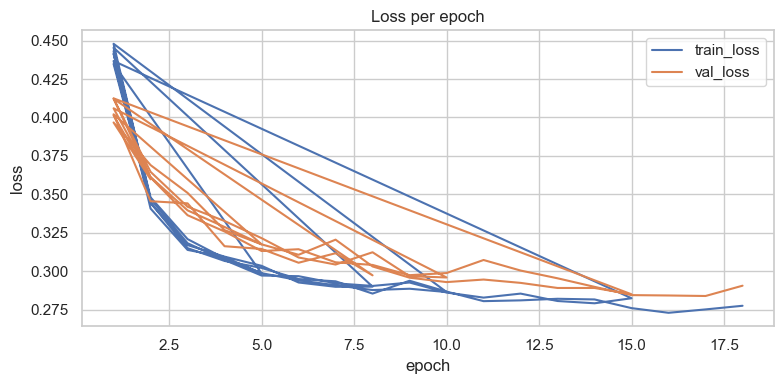

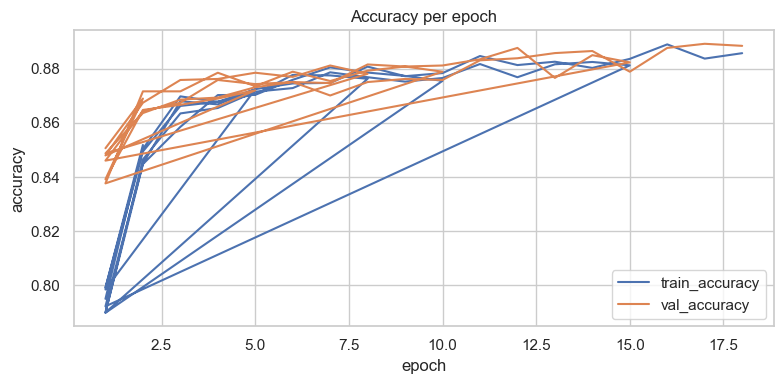

In [3]:
plt.figure(figsize=(8, 4))
plt.plot(df['epoch'], df['train_loss'], label='train_loss')
plt.plot(df['epoch'], df['val_loss'], label='val_loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Loss per epoch')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(df['epoch'], df['train_accuracy'], label='train_accuracy')
plt.plot(df['epoch'], df['val_accuracy'], label='val_accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.title('Accuracy per epoch')
plt.legend()
plt.tight_layout()
plt.show()

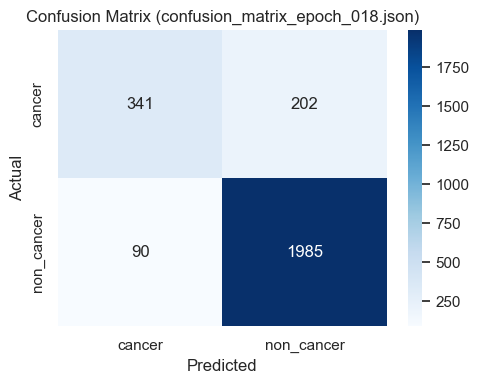

In [4]:
pattern = re.compile(r'confusion_matrix_epoch_(\d+)\.json$')
candidates = []
for path in outputs_dir.glob('confusion_matrix_epoch_*.json'):
    match = pattern.match(path.name)
    if match:
        candidates.append((int(match.group(1)), path))

if not candidates:
    raise FileNotFoundError('No confusion_matrix_epoch_*.json files found in outputs/')

latest_path = max(candidates, key=lambda x: x[0])[1]
with open(latest_path, 'r', encoding='utf8') as f:
    data = json.load(f)

labels = data.get('labels') or ['0', '1']
matrix = data.get('matrix') or data.get('confusion_matrix')
if matrix is None:
    raise ValueError('Confusion JSON must contain a "matrix" or "confusion_matrix" key')

plt.figure(figsize=(5, 4))
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix ({latest_path.name})')
plt.tight_layout()
plt.show()